# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
| Muhammad Farid Wijdan             |   5054251042    |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [124]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.
df = pd.read_csv('WineQT.csv')
df.head()
df.info()
df.describe()
#! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan. 
df = df.drop(columns=["Id"])

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [126]:
df_missing = df.isnull().sum()
df_duplicate = df.duplicated().sum()

In [127]:
df_missing

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [128]:
df_duplicate

np.int64(125)

In [129]:
df = df.drop_duplicates()
df.info()
df.describe()
df.duplicated().sum()

<class 'pandas.DataFrame'>
Index: 1018 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1018 non-null   float64
 1   volatile acidity      1018 non-null   float64
 2   citric acid           1018 non-null   float64
 3   residual sugar        1018 non-null   float64
 4   chlorides             1018 non-null   float64
 5   free sulfur dioxide   1018 non-null   float64
 6   total sulfur dioxide  1018 non-null   float64
 7   density               1018 non-null   float64
 8   pH                    1018 non-null   float64
 9   sulphates             1018 non-null   float64
 10  alcohol               1018 non-null   float64
 11  quality               1018 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 103.4 KB


np.int64(0)

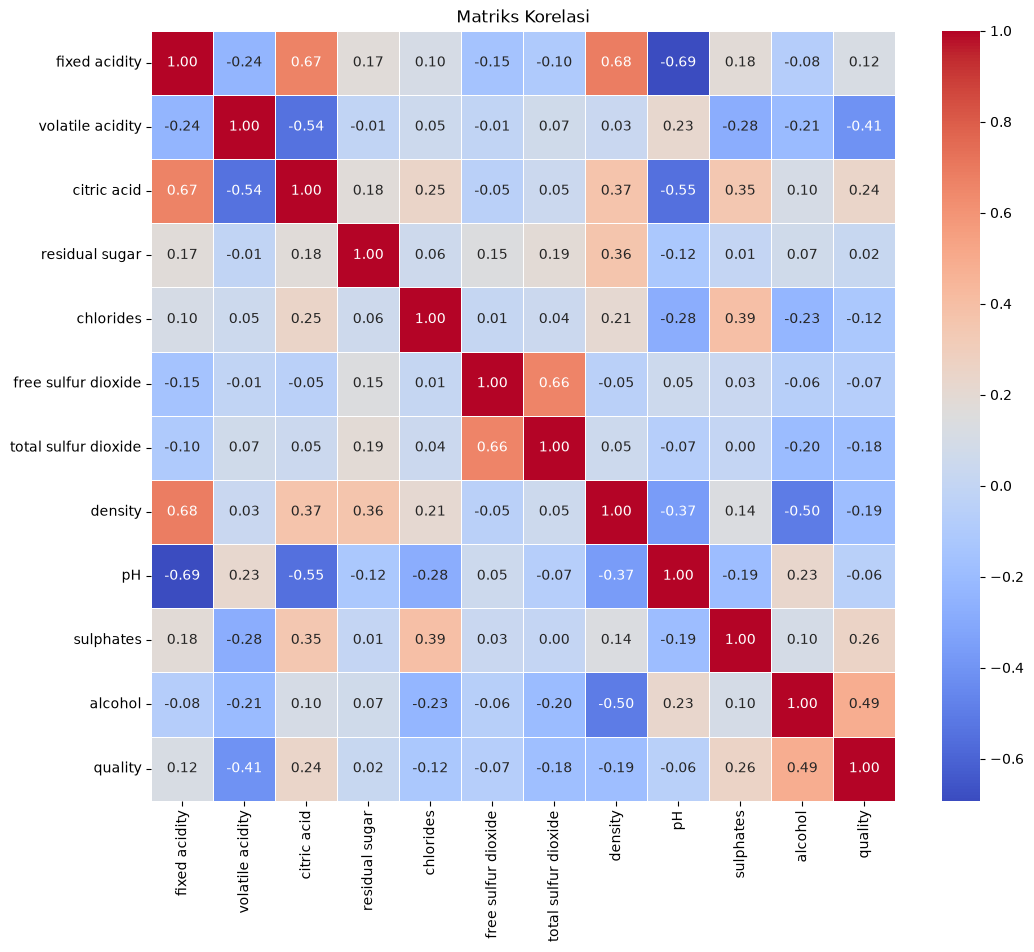

In [130]:
# Tampilkan Korelasi Matrix
matrix = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi")
plt.show()

<Figure size 1200x1000 with 0 Axes>

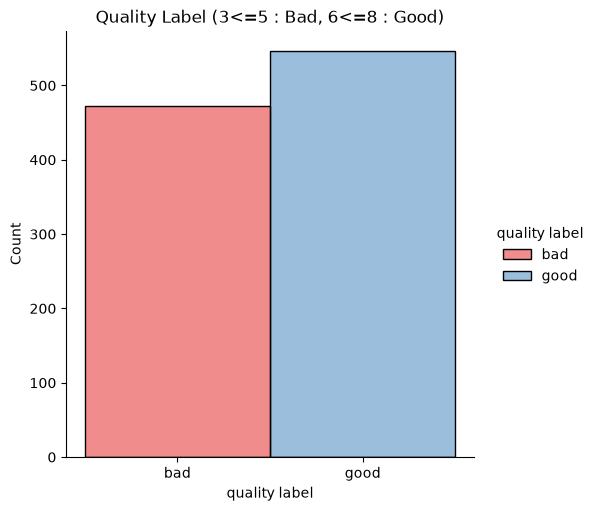

In [131]:
df['quality label'] = np.where(df['quality'] >= 6, 'good', 'bad')
df_drop_korelasi_kecil = df.drop(columns=["residual sugar", "free sulfur dioxide", "pH","chlorides"])
plt.figure(figsize=(12,10))
sns.displot(data=df,x="quality label", bins=2, hue="quality label", palette="Set1")
plt.title("Quality Label (3<=5 : Bad, 6<=8 : Good)")
plt.show()

<Figure size 800x600 with 0 Axes>

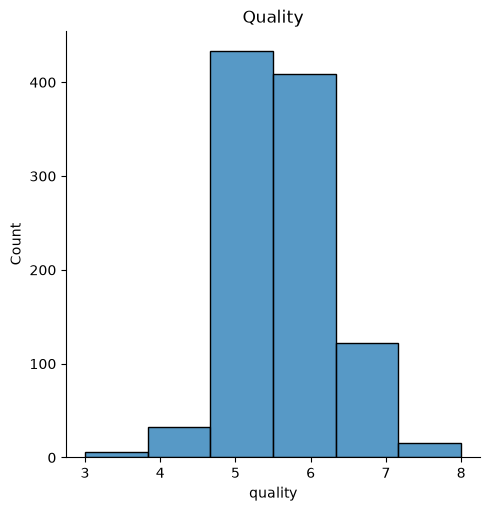

In [132]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.
plt.figure(figsize=(8,6))
sns.displot(x='quality',data=df, bins=6)
plt.title("Quality")
plt.show()

## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

# 2. Preprocessing




In [133]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.


# *Data memikili 125 duplikat (sudah di drop di atas) dan data tidak ada yang Missing value*

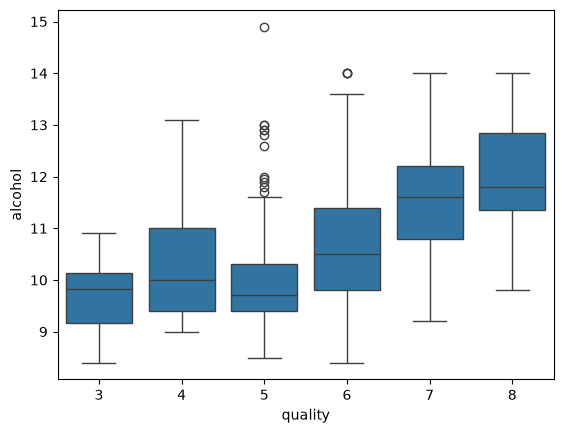

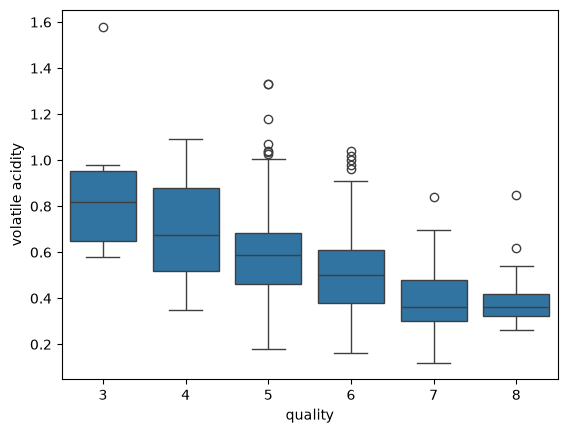

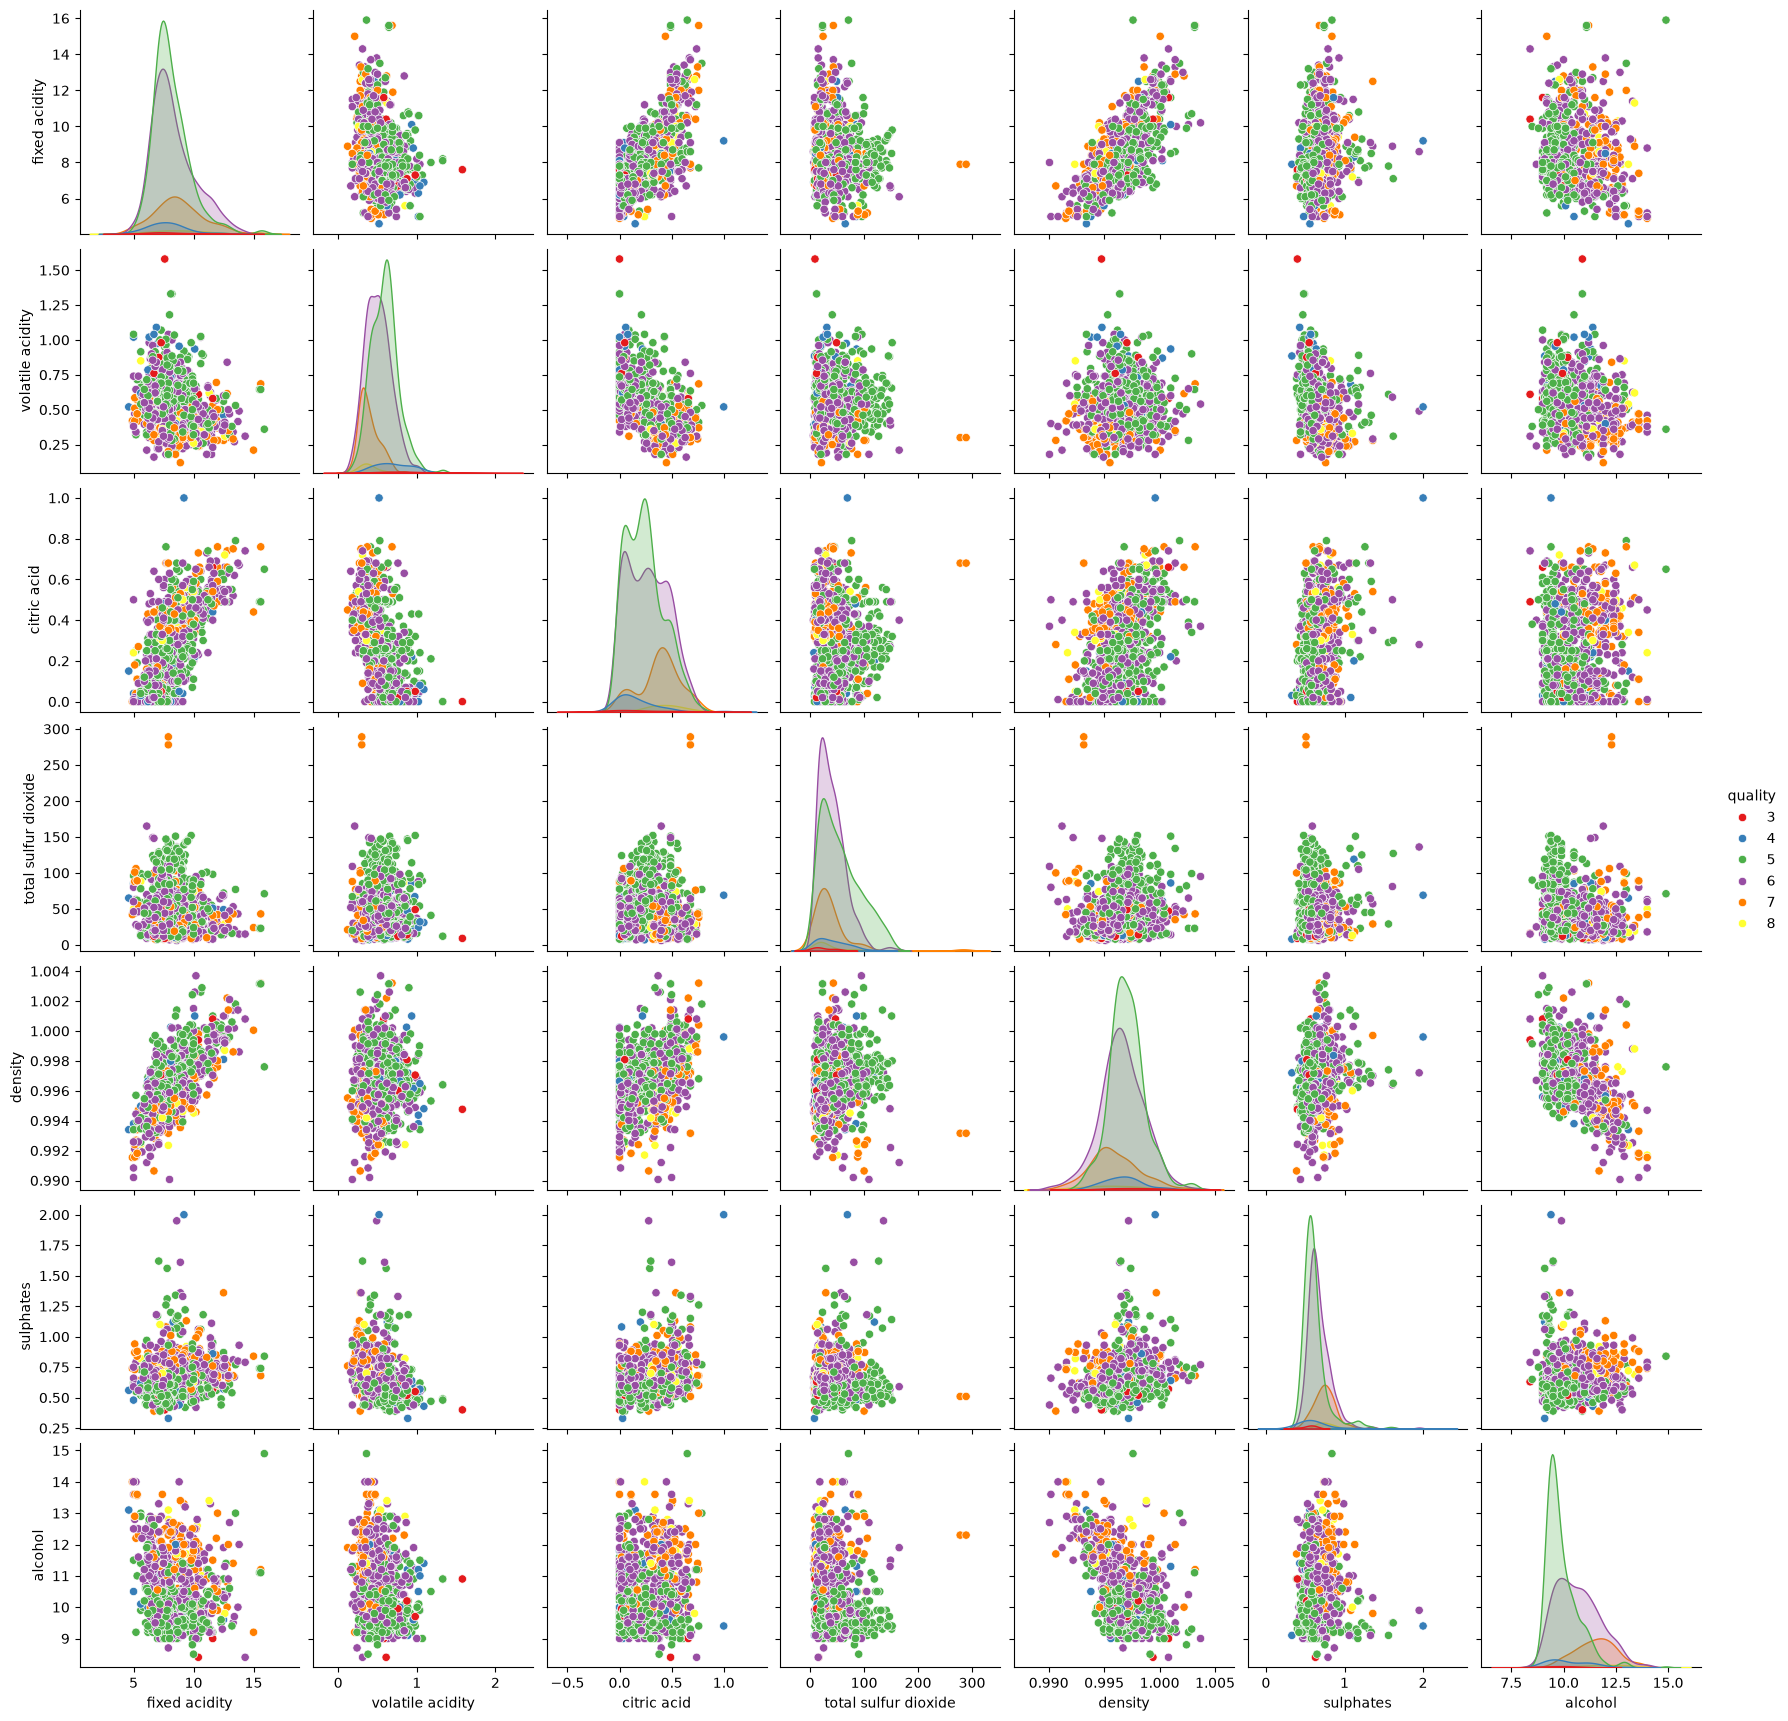

In [134]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)
sns.boxplot(x=df["quality"], y=df["alcohol"])
plt.show()
sns.boxplot(x=df["quality"], y=df["volatile acidity"])
plt.show()
sns.pairplot(
    df_drop_korelasi_kecil,
    hue="quality",
    palette="Set1",
)

plt.show()

In [135]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.
# Split data menjadi train dan test set. (misal 80% train, 20% test)
x = df_drop_korelasi_kecil.drop(columns=["quality", "quality label"])
y = df_drop_korelasi_kecil["quality label"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

minmax_scaler = MinMaxScaler()
x_train_scaled_minmax = minmax_scaler.fit_transform(x_train)
x_test_scaled_minmax = minmax_scaler.transform(x_test)

# 3. Eksperimen Model KNN


In [136]:
k_values = [1, 3, 5, 7, 9]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, p=1, weights="uniform") 
    knn.fit(x_train_scaled, y_train)
    train_score = knn.score(x_train_scaled, y_train)
    test_score = knn.score(x_test_scaled, y_test)
    print(f"k={k}: Train Score (Standar Scaler)={train_score:.4f}, Test Score={test_score:.4f}")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, p=1, weights="uniform")
    knn.fit(x_train_scaled_minmax, y_train)
    train_score = knn.score(x_train_scaled_minmax, y_train)
    test_score = knn.score(x_test_scaled_minmax, y_test)
    print(f"k={k} (MinMax): Train Score={train_score:.4f}, Test Score={test_score:.4f}")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, p=1, weights="uniform")
    knn.fit(x_train, y_train)
    train_score = knn.score(x_train, y_train)
    test_score = knn.score(x_test, y_test)
    print(f"k={k} (No Scaling): Train Score={train_score:.4f}, Test Score={test_score:.4f}")

k=1: Train Score (Standar Scaler)=1.0000, Test Score=0.6127
k=3: Train Score (Standar Scaler)=0.8415, Test Score=0.6814
k=5: Train Score (Standar Scaler)=0.7948, Test Score=0.7353
k=7: Train Score (Standar Scaler)=0.7899, Test Score=0.7304
k=9: Train Score (Standar Scaler)=0.7727, Test Score=0.7255
k=1 (MinMax): Train Score=1.0000, Test Score=0.6520
k=3 (MinMax): Train Score=0.8428, Test Score=0.6961
k=5 (MinMax): Train Score=0.7998, Test Score=0.7108
k=7 (MinMax): Train Score=0.7961, Test Score=0.7206
k=9 (MinMax): Train Score=0.7826, Test Score=0.7353
k=1 (No Scaling): Train Score=1.0000, Test Score=0.5784
k=3 (No Scaling): Train Score=0.8096, Test Score=0.6078
k=5 (No Scaling): Train Score=0.7887, Test Score=0.5784
k=7 (No Scaling): Train Score=0.7604, Test Score=0.6029
k=9 (No Scaling): Train Score=0.7715, Test Score=0.6078


# 4. Evaluasi Model


Evaluasi Model KNN dengan Standar Scaler:
k=1: Train Score=1.0000, Test Score=0.6127
              precision    recall  f1-score   support

         bad       0.58      0.62      0.60        95
        good       0.65      0.61      0.63       109

    accuracy                           0.61       204
   macro avg       0.61      0.61      0.61       204
weighted avg       0.62      0.61      0.61       204

[[59 36]
 [43 66]]


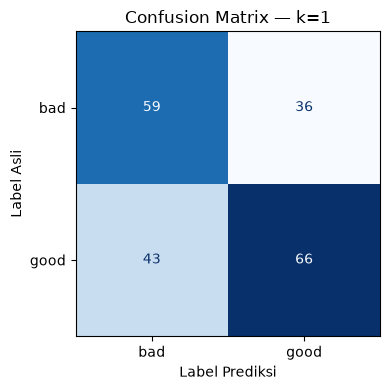

k=3: Train Score=0.8415, Test Score=0.6814
              precision    recall  f1-score   support

         bad       0.67      0.61      0.64        95
        good       0.69      0.74      0.71       109

    accuracy                           0.68       204
   macro avg       0.68      0.68      0.68       204
weighted avg       0.68      0.68      0.68       204

[[58 37]
 [28 81]]


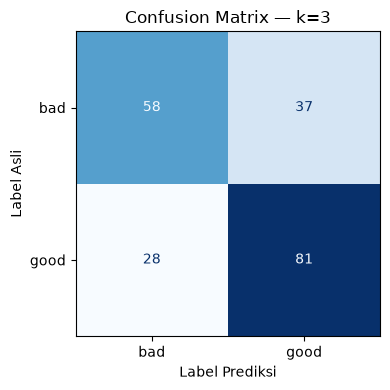

k=5: Train Score=0.7948, Test Score=0.7353
              precision    recall  f1-score   support

         bad       0.72      0.72      0.72        95
        good       0.75      0.75      0.75       109

    accuracy                           0.74       204
   macro avg       0.73      0.73      0.73       204
weighted avg       0.74      0.74      0.74       204

[[68 27]
 [27 82]]


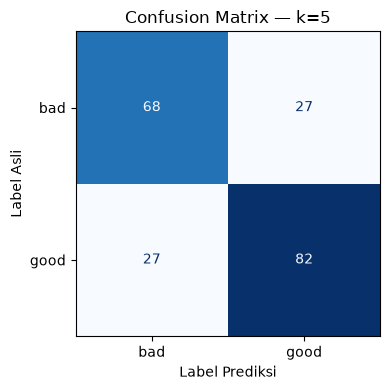

k=7: Train Score=0.7899, Test Score=0.7304
              precision    recall  f1-score   support

         bad       0.71      0.72      0.71        95
        good       0.75      0.74      0.75       109

    accuracy                           0.73       204
   macro avg       0.73      0.73      0.73       204
weighted avg       0.73      0.73      0.73       204

[[68 27]
 [28 81]]


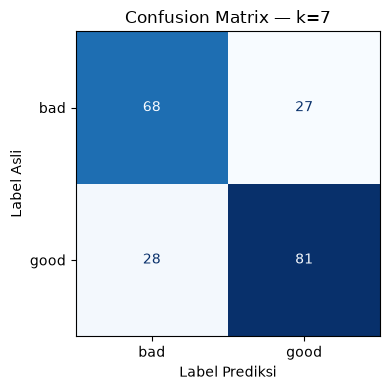

k=9: Train Score=0.7727, Test Score=0.7255
              precision    recall  f1-score   support

         bad       0.70      0.72      0.71        95
        good       0.75      0.73      0.74       109

    accuracy                           0.73       204
   macro avg       0.72      0.72      0.72       204
weighted avg       0.73      0.73      0.73       204

[[68 27]
 [29 80]]


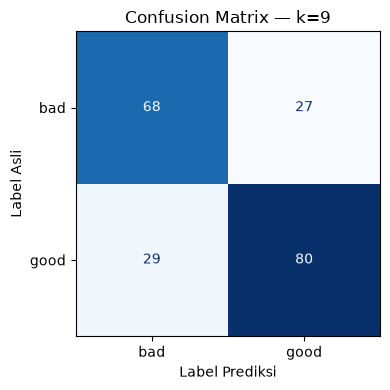

In [137]:
from sklearn.metrics import ConfusionMatrixDisplay

# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

k_values = [1, 3, 5, 7, 9]
print("Evaluasi Model KNN dengan Standar Scaler:")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, p=1, weights="uniform")
    knn.fit(x_train_scaled, y_train)
    y_pred = knn.predict(x_test_scaled)
    train_score = knn.score(x_train_scaled, y_train)
    test_score = knn.score(x_test_scaled, y_test)
    print(f"k={k}: Train Score={train_score:.4f}, Test Score={test_score:.4f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
                y_test,
                y_pred,
                labels=["bad", "good"],
                cmap="Blues",
                values_format="d",
                colorbar=False,
                ax=ax
            )
    ax.set_title(f"Confusion Matrix — k={k}")
    ax.set_xlabel("Label Prediksi")
    ax.set_ylabel("Label Asli")
    plt.tight_layout()
    plt.show()




Evaluasi Model KNN dengan MinMax Scaler:
k=1: Train Score=1.0000, Test Score=0.6520
              precision    recall  f1-score   support

         bad       0.62      0.66      0.64        95
        good       0.69      0.64      0.66       109

    accuracy                           0.65       204
   macro avg       0.65      0.65      0.65       204
weighted avg       0.65      0.65      0.65       204

[[63 32]
 [39 70]]


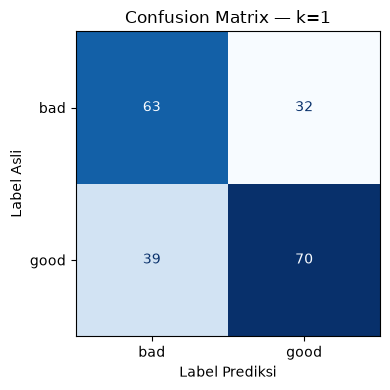

k=3: Train Score=0.8428, Test Score=0.6961
              precision    recall  f1-score   support

         bad       0.67      0.67      0.67        95
        good       0.72      0.72      0.72       109

    accuracy                           0.70       204
   macro avg       0.69      0.69      0.69       204
weighted avg       0.70      0.70      0.70       204

[[64 31]
 [31 78]]


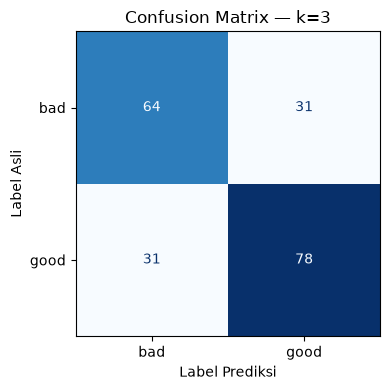

k=5: Train Score=0.7998, Test Score=0.7108
              precision    recall  f1-score   support

         bad       0.69      0.69      0.69        95
        good       0.73      0.72      0.73       109

    accuracy                           0.71       204
   macro avg       0.71      0.71      0.71       204
weighted avg       0.71      0.71      0.71       204

[[66 29]
 [30 79]]


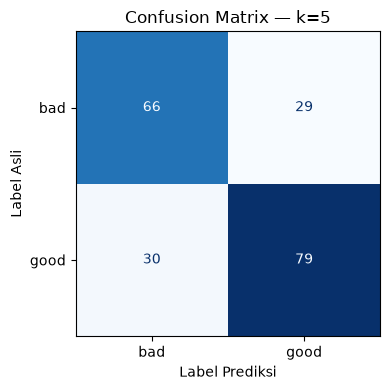

k=7: Train Score=0.7961, Test Score=0.7206
              precision    recall  f1-score   support

         bad       0.70      0.71      0.70        95
        good       0.74      0.73      0.74       109

    accuracy                           0.72       204
   macro avg       0.72      0.72      0.72       204
weighted avg       0.72      0.72      0.72       204

[[67 28]
 [29 80]]


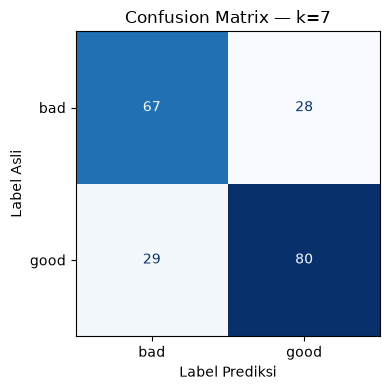

k=9: Train Score=0.7826, Test Score=0.7353
              precision    recall  f1-score   support

         bad       0.71      0.73      0.72        95
        good       0.76      0.74      0.75       109

    accuracy                           0.74       204
   macro avg       0.73      0.73      0.73       204
weighted avg       0.74      0.74      0.74       204

[[69 26]
 [28 81]]


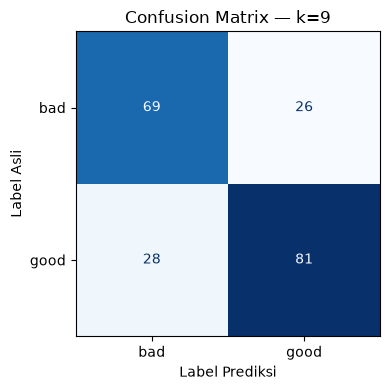

In [138]:
print("Evaluasi Model KNN dengan MinMax Scaler:")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, p=1, weights="uniform")
    knn.fit(x_train_scaled_minmax, y_train)
    y_pred = knn.predict(x_test_scaled_minmax)
    train_score = knn.score(x_train_scaled_minmax, y_train)
    test_score = knn.score(x_test_scaled_minmax, y_test)
    print(f"k={k}: Train Score={train_score:.4f}, Test Score={test_score:.4f}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
                y_test,
                y_pred,
                labels=["bad", "good"],
                cmap="Blues",
                values_format="d",
                colorbar=False,
                ax=ax
            )
    ax.set_title(f"Confusion Matrix — k={k}")
    ax.set_xlabel("Label Prediksi")
    ax.set_ylabel("Label Asli")
    plt.tight_layout()
    plt.show()

Evaluasi Model KNN dengan No Scaling:
k=1: Train Score=1.0000, Test Score=0.5784
              precision    recall  f1-score   support

         bad       0.55      0.56      0.55        95
        good       0.61      0.60      0.60       109

    accuracy                           0.58       204
   macro avg       0.58      0.58      0.58       204
weighted avg       0.58      0.58      0.58       204



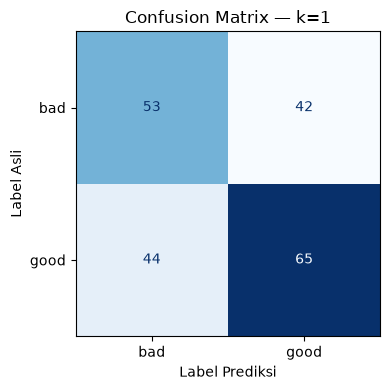

k=3: Train Score=0.8096, Test Score=0.6078
              precision    recall  f1-score   support

         bad       0.58      0.60      0.59        95
        good       0.64      0.61      0.63       109

    accuracy                           0.61       204
   macro avg       0.61      0.61      0.61       204
weighted avg       0.61      0.61      0.61       204



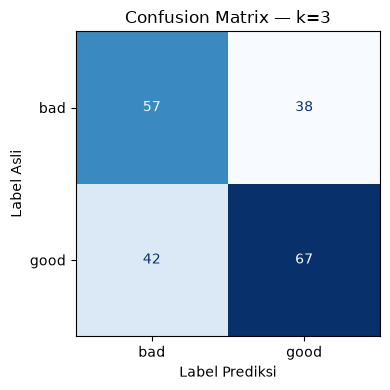

k=5: Train Score=0.7887, Test Score=0.5784
              precision    recall  f1-score   support

         bad       0.55      0.55      0.55        95
        good       0.61      0.61      0.61       109

    accuracy                           0.58       204
   macro avg       0.58      0.58      0.58       204
weighted avg       0.58      0.58      0.58       204



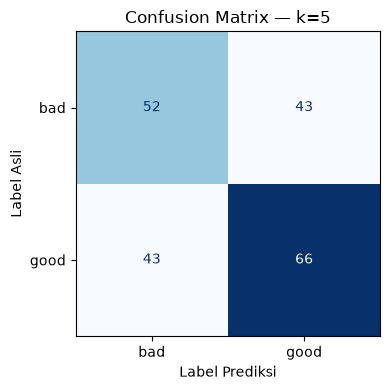

k=7: Train Score=0.7604, Test Score=0.6029
              precision    recall  f1-score   support

         bad       0.57      0.60      0.58        95
        good       0.63      0.61      0.62       109

    accuracy                           0.60       204
   macro avg       0.60      0.60      0.60       204
weighted avg       0.60      0.60      0.60       204



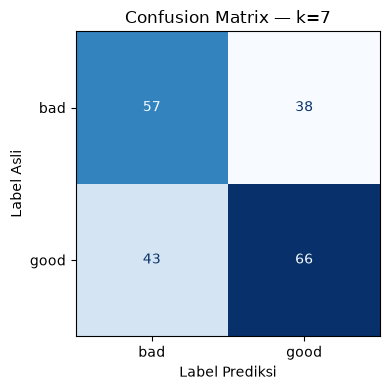

k=9: Train Score=0.7715, Test Score=0.6078
              precision    recall  f1-score   support

         bad       0.58      0.59      0.58        95
        good       0.64      0.62      0.63       109

    accuracy                           0.61       204
   macro avg       0.61      0.61      0.61       204
weighted avg       0.61      0.61      0.61       204



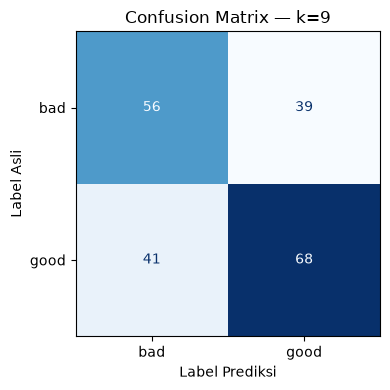

In [139]:
print("Evaluasi Model KNN dengan No Scaling:")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, p=1, weights="uniform")
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    train_score = knn.score(x_train, y_train)
    test_score = knn.score(x_test, y_test)
    print(f"k={k}: Train Score={train_score:.4f}, Test Score={test_score:.4f}")
    print(classification_report(y_test, y_pred))
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred,
            labels=["bad", "good"],
            cmap="Blues",
            values_format="d",
            colorbar=False,
            ax=ax
        )
    ax.set_title(f"Confusion Matrix — k={k}")
    ax.set_xlabel("Label Prediksi")
    ax.set_ylabel("Label Asli")
    plt.tight_layout()
    plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

## Analisis Hasil Eksperimen

Berdasarkan seluruh eksperimen, performa KNN dipengaruhi oleh nilai `k`, metrik jarak, dan metode scaling yang digunakan.

### 1. Pengaruh Nilai k

Pada hampir seluruh eksperimen, `k=1` menghasilkan akurasi training sebesar 1,00, tetapi akurasi testing relatif rendah. Hal ini menunjukkan bahwa model mengalami overfitting karena hanya bergantung pada satu tetangga terdekat.

Ketika nilai `k` dinaikkan menjadi 3, 5, 7, dan 9, akurasi training menurun, tetapi performa testing menjadi lebih stabil. Nilai terbaik secara umum diperoleh pada `k=5` untuk StandardScaler, sedangkan pada MinMaxScaler performa terbaik cenderung diperoleh pada `k=9`.

### 2. Perbandingan Metrik Jarak

Pada StandardScaler, metrik Euclidean memberikan hasil terbaik:

- `k=5`
- Akurasi testing: **75,00%**
- Precision: **76,36%**
- Recall: **77,06%**
- F1-Score: **76,71%**

Hasil ini sedikit lebih baik dibandingkan Manhattan pada `k=5`, yang memperoleh akurasi testing sebesar **73,53%** dan F1-Score sebesar **75,23%**.

Pada MinMaxScaler, Manhattan dengan `k=9` menghasilkan akurasi testing sebesar **73,53%**, sedangkan Euclidean dengan `k=9` memperoleh **72,55%**. Dengan demikian, metrik Euclidean paling efektif pada StandardScaler, sementara Manhattan sedikit lebih baik pada MinMaxScaler.

### 3. Perbandingan Metode Scaling

StandardScaler menghasilkan performa terbaik secara keseluruhan. Kombinasi terbaik adalah:

- Scaling: **StandardScaler**
- Metrik jarak: **Euclidean**
- `k=5`
- Akurasi testing: **75,00%**
- F1-Score: **76,71%**

MinMaxScaler menghasilkan performa yang cukup baik, tetapi skor tertingginya hanya mencapai akurasi **73,53%**.

Eksperimen tanpa scaling memberikan hasil paling rendah. Akurasi testing terbaiknya hanya sekitar **61,27%**, sedangkan beberapa kombinasi lainnya berada di bawah 60%. Hal ini terjadi karena setiap fitur memiliki rentang nilai yang berbeda. Fitur dengan nilai numerik besar, seperti `total sulfur dioxide`, dapat mendominasi perhitungan jarak apabila data tidak diskalakan.

### 4. Perbandingan Train dan Test Accuracy

Model dengan `k=1` memiliki perbedaan besar antara akurasi training dan testing. Contohnya, pada StandardScaler dan Euclidean, akurasi training mencapai **100%**, tetapi akurasi testing hanya **64,22%**. Ini merupakan indikasi overfitting.

Pada konfigurasi terbaik, yaitu StandardScaler, Euclidean, dan `k=5`, akurasi training sebesar **81,08%** dan akurasi testing sebesar **75,00%**. Selisih performanya lebih kecil sehingga model memiliki kemampuan generalisasi yang lebih baik.

### 5. Evaluasi Precision, Recall, dan F1-Score

Konfigurasi StandardScaler dengan metrik Euclidean dan `k=5` juga menghasilkan nilai precision, recall, dan F1-Score tertinggi secara keseluruhan. Nilai recall sebesar **77,06%** menunjukkan bahwa model cukup baik dalam mengenali wine yang termasuk ke dalam kelas target.

F1-Score sebesar **76,71%** menunjukkan keseimbangan yang baik antara precision dan recall. Oleh karena itu, konfigurasi ini lebih disarankan dibandingkan hanya memilih model berdasarkan akurasi.

### 6. Kesimpulan Analisis

Hasil eksperimen menunjukkan bahwa scaling sangat penting dalam algoritma KNN karena algoritma ini bergantung pada perhitungan jarak. StandardScaler memberikan hasil terbaik dibandingkan MinMaxScaler dan data tanpa scaling.

Model terbaik dari seluruh eksperimen adalah KNN dengan:

- `StandardScaler`
- Jarak Euclidean
- `k=5`

Model tersebut memperoleh akurasi testing **75,00%**, precision **76,36%**, recall **77,06%**, dan F1-Score **76,71%**. Nilai `k=5` mampu mengurangi overfitting yang terlihat pada `k=1`, sekaligus mempertahankan performa klasifikasi yang baik.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

## Kesimpulan

Berdasarkan eksperimen yang telah dilakukan, model KNN dipengaruhi oleh nilai `k`, metrik jarak, dan metode scaling. Penggunaan scaling terbukti penting karena KNN menghitung jarak antar data.

Model terbaik diperoleh dengan konfigurasi:

- **Scaling:** StandardScaler
- **Metrik jarak:** Euclidean
- **Nilai k:** 5
- **Akurasi testing:** 75,00%
- **Precision:** 76,36%
- **Recall:** 77,06%
- **F1-Score:** 76,71%

Nilai `k=1` menghasilkan akurasi training 100%, tetapi performa testing lebih rendah sehingga menunjukkan gejala overfitting. Peningkatan nilai `k` membuat model lebih stabil. StandardScaler juga memberikan hasil terbaik dibandingkan MinMaxScaler dan data tanpa scaling. Tanpa scaling, akurasi tertinggi hanya sekitar 61,27% karena fitur dengan skala besar dapat mendominasi perhitungan jarak.

## Saran

1. Menggunakan **StandardScaler, metrik Euclidean, dan k=5** sebagai konfigurasi utama.
2. Melakukan **cross-validation** agar pemilihan nilai `k` tidak hanya bergantung pada satu pembagian data.
3. Mencoba optimasi parameter lain, seperti `weights="distance"` dan nilai `k` yang lebih beragam.
4. Menangani ketidakseimbangan kelas apabila distribusi label `good` dan `bad` tidak seimbang.
5. Membandingkan KNN dengan model lain, seperti Decision Tree, Random Forest, SVM, atau Logistic Regression.
6. Melakukan analisis outlier dan pemilihan fitur secara lebih sistematis untuk meningkatkan performa model.